# Eksploracija sintetičkih PK profila vankomicina

Generisano iz `src/data_processing.py` — jednoodeljni IV model, 50 virtualnih pacijenata.

Parametri populacije:
- CL ~ LogNormal(3.5 L/h, CV=30%)
- Vd ~ LogNormal(50 L, CV=25%)
- Doza: 1000 mg IV bolus

In [1]:
import sys
sys.path.insert(0, "..")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import seaborn as sns
from pathlib import Path

PROC_DIR = Path("../data/processed")
RAW_DIR  = Path("../data/raw")

profiles  = pd.read_csv(PROC_DIR / "subject_profiles.csv")
gt_params = pd.read_csv(PROC_DIR / "ground_truth_params.csv")

print(f"Subjekata: {gt_params.shape[0]}")
print(f"Merenja ukupno: {profiles.shape[0]}")
print()
print(gt_params[["k10", "Vd", "CL", "half_life_h", "AUC"]].describe().round(3))

Subjekata: 50
Merenja ukupno: 600

          k10      Vd      CL  half_life_h      AUC
count  50.000  50.000  50.000       50.000   50.000
mean    0.078  47.076   3.529        9.733  297.829
std     0.023   8.781   0.795        2.962   69.244
min     0.042  32.017   1.891        5.119  159.075
25%     0.061  41.271   2.961        7.768  247.063
50%     0.075  45.140   3.528        9.257  283.527
75%     0.089  54.522   4.048       11.442  337.720
max     0.135  70.091   6.286       16.352  528.915


## 1. PK profili svih subjekata

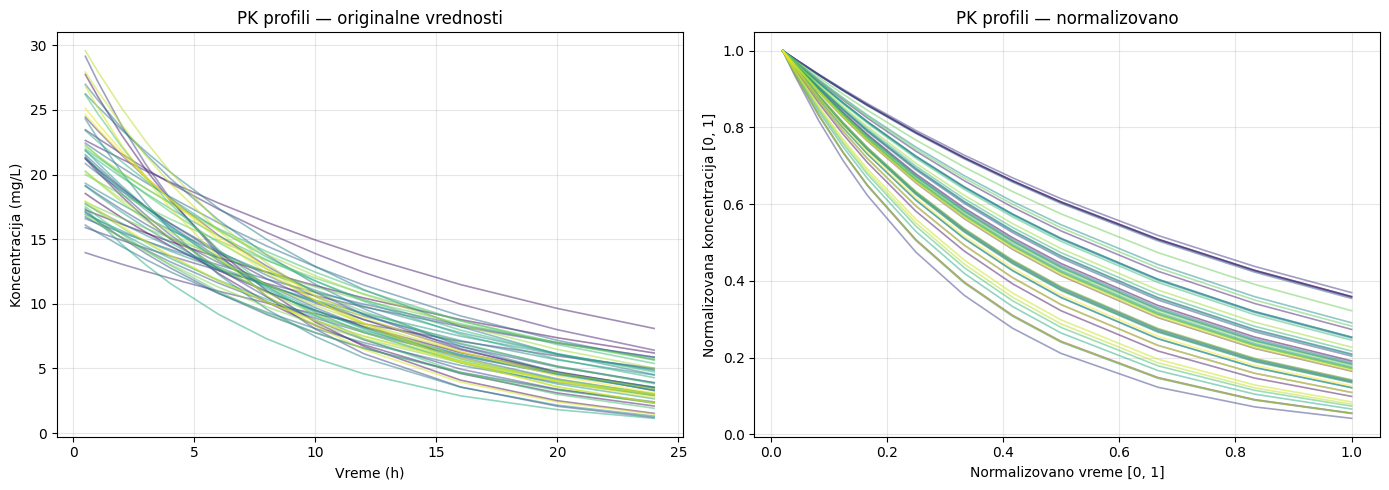

In [2]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# --- Levo: originalne vrednosti ---
ax = axes[0]
colors = cm.viridis(np.linspace(0, 1, gt_params.shape[0]))
for (sid, grp), color in zip(profiles.groupby("subject_id"), colors):
    ax.plot(grp["time_h"], grp["C_true"], alpha=0.5, lw=1.2, color=color)
ax.set_xlabel("Vreme (h)")
ax.set_ylabel("Koncentracija (mg/L)")
ax.set_title("PK profili — originalne vrednosti")
ax.grid(True, alpha=0.3)

# --- Desno: normalizovano ---
ax = axes[1]
for (sid, grp), color in zip(profiles.groupby("subject_id"), colors):
    ax.plot(grp["time_norm"], grp["C_norm"], alpha=0.5, lw=1.2, color=color)
ax.set_xlabel("Normalizovano vreme [0, 1]")
ax.set_ylabel("Normalizovana koncentracija [0, 1]")
ax.set_title("PK profili — normalizovano")
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("../results/figures/pk_profiles.png", dpi=150, bbox_inches="tight")
plt.show()

## 2. Distribucija populacionih parametara

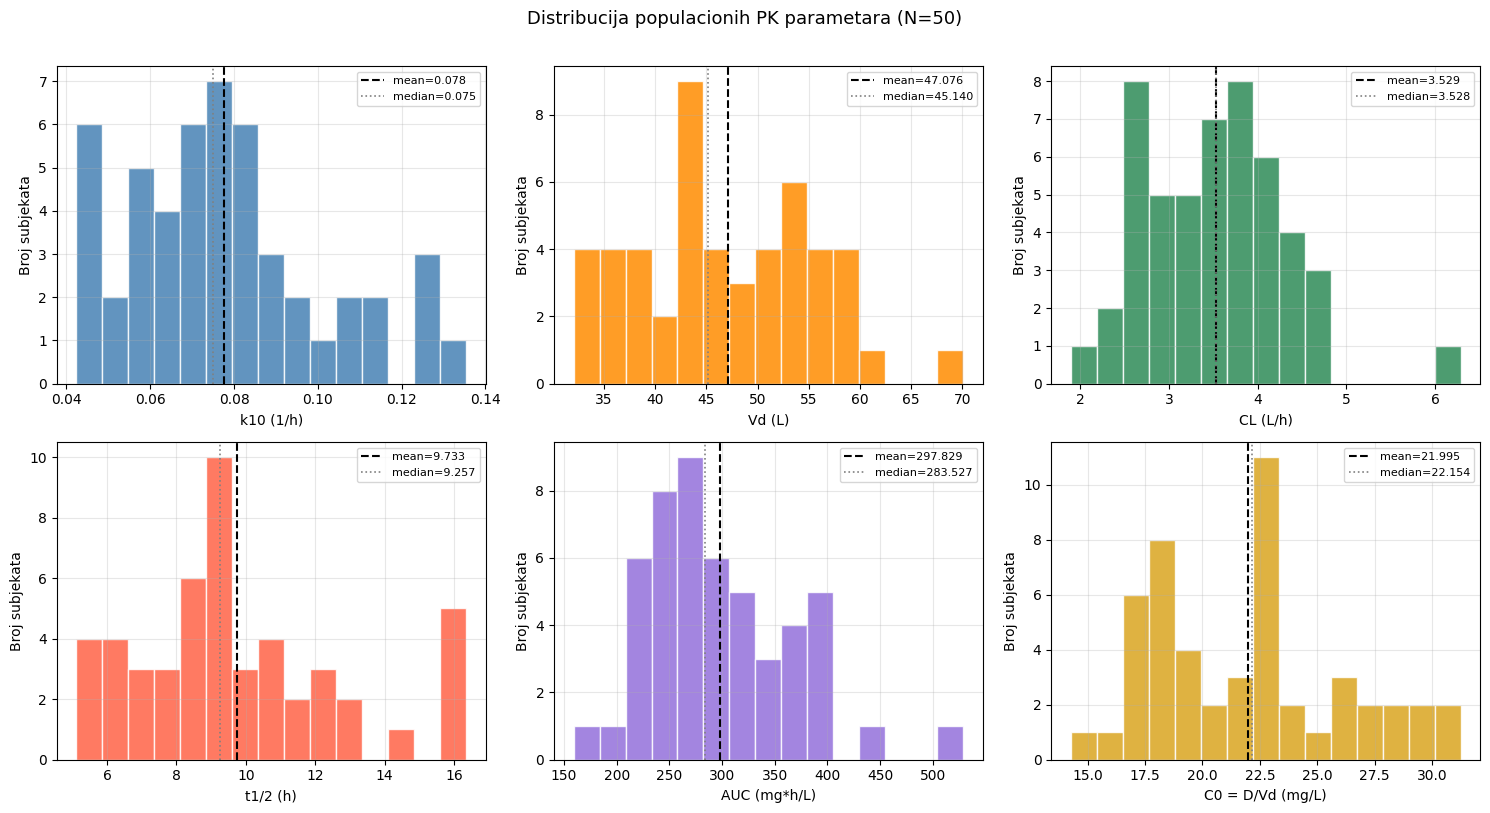

In [3]:
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
params = [
    ("k10",        "k10 (1/h)",       "steelblue"),
    ("Vd",         "Vd (L)",          "darkorange"),
    ("CL",         "CL (L/h)",        "seagreen"),
    ("half_life_h","t1/2 (h)",        "tomato"),
    ("AUC",        "AUC (mg*h/L)",    "mediumpurple"),
    ("C0",         "C0 = D/Vd (mg/L)","goldenrod"),
]

for ax, (col, label, color) in zip(axes.flat, params):
    ax.hist(gt_params[col], bins=15, color=color, edgecolor="white", alpha=0.85)
    ax.axvline(gt_params[col].mean(), color="black", lw=1.5, ls="--", label=f"mean={gt_params[col].mean():.3f}")
    ax.axvline(gt_params[col].median(), color="gray", lw=1.2, ls=":", label=f"median={gt_params[col].median():.3f}")
    ax.set_xlabel(label)
    ax.set_ylabel("Broj subjekata")
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)

plt.suptitle("Distribucija populacionih PK parametara (N=50)", fontsize=13, y=1.01)
plt.tight_layout()
plt.savefig("../results/figures/param_distributions.png", dpi=150, bbox_inches="tight")
plt.show()

## 3. Prikaz proređivanja merenja

Simulacija kako izgledaju podaci sa N=3, 5, 8 tačaka uz šum σ=10%.

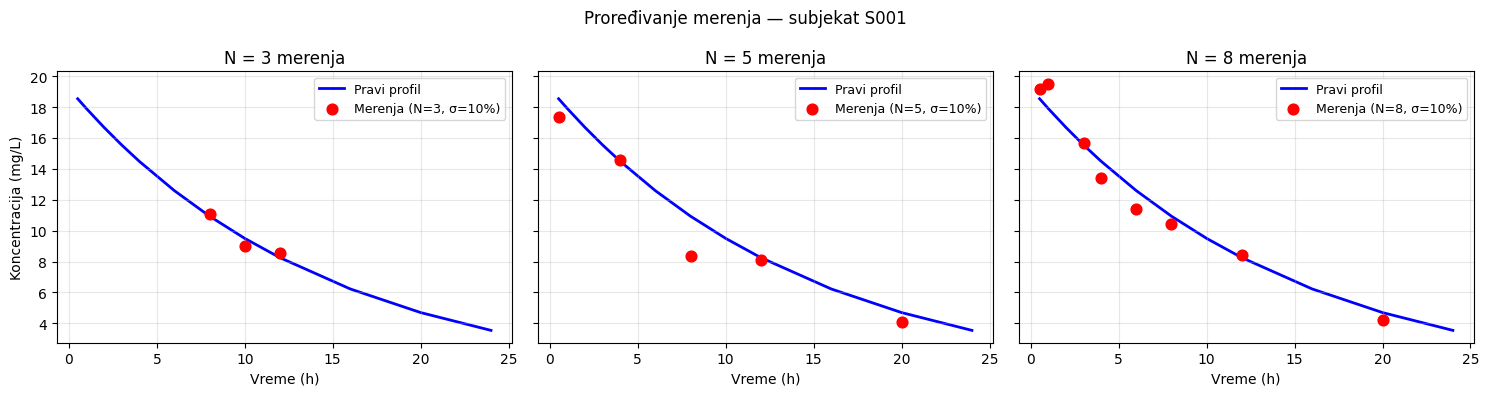

In [4]:
rng = np.random.default_rng(0)
OBS_TIMES = np.array([0.5,1,2,3,4,6,8,10,12,16,20,24])

# Uzmi prvog subjekta za prikaz
sid = "S001"
subj = profiles[profiles["subject_id"] == sid]
t_full = subj["time_h"].values
C_full = subj["C_true"].values

fig, axes = plt.subplots(1, 3, figsize=(15, 4), sharey=True)
sigma = 0.10

for ax, N in zip(axes, [3, 5, 8]):
    idx = np.sort(rng.choice(len(t_full), N, replace=False))
    t_sparse = t_full[idx]
    C_noisy  = C_full[idx] * (1 + rng.normal(0, sigma, N))

    ax.plot(t_full, C_full, "b-", lw=2, label="Pravi profil", zorder=1)
    ax.scatter(t_sparse, C_noisy, color="red", zorder=5, s=60, label=f"Merenja (N={N}, σ=10%)")
    ax.set_xlabel("Vreme (h)")
    ax.set_title(f"N = {N} merenja")
    ax.legend(fontsize=9)
    ax.grid(True, alpha=0.3)

axes[0].set_ylabel("Koncentracija (mg/L)")
plt.suptitle(f"Proređivanje merenja — subjekat {sid}", fontsize=12)
plt.tight_layout()
plt.savefig("../results/figures/sparse_sampling_example.png", dpi=150, bbox_inches="tight")
plt.show()

## 4. Korelacija između parametara

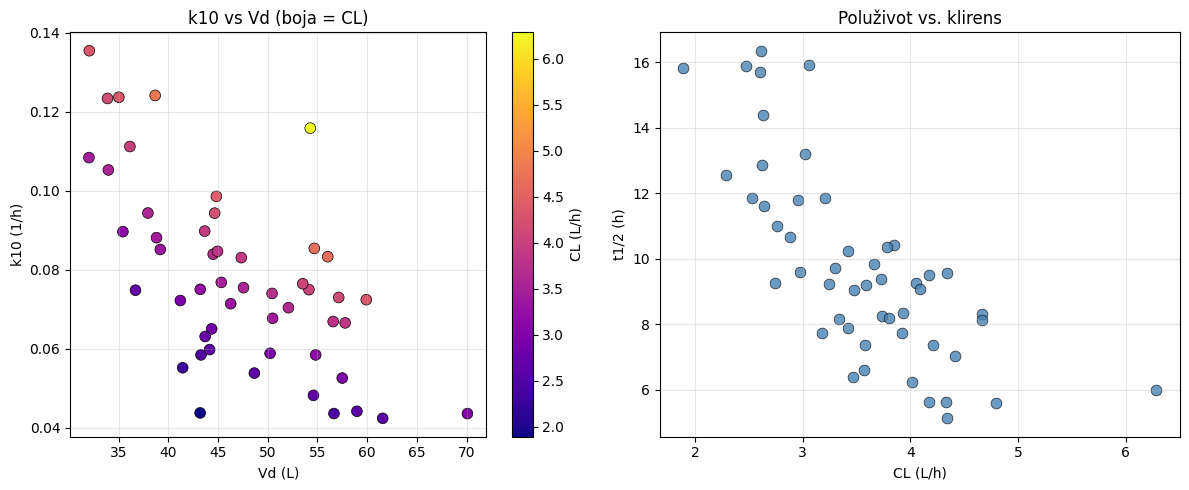


Korelaciona matrica:
               k10     Vd     CL  half_life_h
k10          1.000 -0.648  0.736       -0.940
Vd          -0.648  1.000 -0.007        0.629
CL           0.736 -0.007  1.000       -0.745
half_life_h -0.940  0.629 -0.745        1.000


In [5]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# k10 vs Vd
ax = axes[0]
sc = ax.scatter(gt_params["Vd"], gt_params["k10"],
                c=gt_params["CL"], cmap="plasma", s=60, edgecolors="k", lw=0.5)
plt.colorbar(sc, ax=ax, label="CL (L/h)")
ax.set_xlabel("Vd (L)")
ax.set_ylabel("k10 (1/h)")
ax.set_title("k10 vs Vd (boja = CL)")
ax.grid(True, alpha=0.3)

# t1/2 vs CL
ax = axes[1]
ax.scatter(gt_params["CL"], gt_params["half_life_h"],
           color="steelblue", s=60, edgecolors="k", lw=0.5, alpha=0.8)
ax.set_xlabel("CL (L/h)")
ax.set_ylabel("t1/2 (h)")
ax.set_title("Poluživot vs. klirens")
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("../results/figures/param_correlations.png", dpi=150, bbox_inches="tight")
plt.show()

print("\nKorelaciona matrica:")
print(gt_params[["k10","Vd","CL","half_life_h"]].corr().round(3))